# UK Flight Punctuality Analysis: January 2025

**Data Science Portfolio Project**

This notebook analyses UK Civil Aviation Authority punctuality data to identify patterns in flight delays and cancellations across airports, airlines, and routes.

---

## 1. Setup and Data Loading

In [29]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_r')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


In [30]:
# Load the dataset
df = pd.read_csv('data//202501_Punctuality_Statistics_Full_Analysis_Arrival_Departure.csv')

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

Dataset shape: (5354, 26)

Columns (26):
  - run_date
  - reporting_period
  - reporting_airport
  - origin_destination_country
  - origin_destination
  - airline_name
  - arrival_departure
  - scheduled_charter
  - number_flights_matched
  - actual_flights_unmatched
  - number_flights_cancelled
  - flights_more_than_15_minutes_early_percent
  - flights_15_minutes_early_to_1_minute_early_percent
  - flights_0_to_15_minutes_late_percent
  - flights_between_16_and_30_minutes_late_percent
  - flights_between_31_and_60_minutes_late_percent
  - flights_between_61_and_120_minutes_late_percent
  - flights_between_121_and_180_minutes_late_percent
  - flights_between_181_and_360_minutes_late_percent
  - flights_more_than_360_minutes_late_percent
  - flights_unmatched_percent
  - flights_cancelled_percent
  - average_delay_mins
  - previous_year_month_flights_matched
  - previous_year_month_early_to_15_mins_late_percent
  - previous_year_month_average_delay


In [31]:
# Preview the data
df.head()

,run_date,reporting_period,reporting_airport,origin_destination_country,origin_destination,airline_name,arrival_departure,scheduled_charter,number_flights_matched,actual_flights_unmatched,...,flights_between_61_and_120_minutes_late_percent,flights_between_121_and_180_minutes_late_percent,flights_between_181_and_360_minutes_late_percent,flights_more_than_360_minutes_late_percent,flights_unmatched_percent,flights_cancelled_percent,average_delay_mins,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay
0,14/03/2025 09:52,202501,ABERDEEN,POLAND,GDANSK,WIZZ AIR,A,S,13,0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,4.0,9,44.444444,67.0
1,14/03/2025 09:52,202501,ABERDEEN,POLAND,GDANSK,WIZZ AIR,D,S,13,0,...,7.692308,0.000000,0.000000,0.000000,0.0,0.000000,14.0,9,44.444444,70.0
2,14/03/2025 09:52,202501,ABERDEEN,UNITED KINGDOM,BELFAST CITY (GEORGE BEST),LOGANAIR LTD,A,S,16,0,...,0.000000,0.000000,5.882353,5.882353,0.0,5.882353,52.0,15,38.888889,49.0
3,14/03/2025 09:52,202501,ABERDEEN,UNITED KINGDOM,BELFAST CITY (GEORGE BEST),LOGANAIR LTD,D,S,16,0,...,0.000000,0.000000,5.882353,5.882353,0.0,5.882353,53.0,16,44.444444,47.0
4,14/03/2025 09:52,202501,ABERDEEN,UNITED KINGDOM,BIRMINGHAM,LOGANAIR LTD,A,S,50,0,...,3.773585,3.773585,3.773585,0.000000,0.0,5.660377,23.0,53,75.438596,15.0


## 2. Data Engineering

### 2.1 Data Profiling

In [32]:
# Check for missing values in key columns
key_cols = ['reporting_airport', 'airline_name', 'number_flights_matched', 
            'number_flights_cancelled', 'average_delay_mins']

print("Missing values in key columns:")
print(df[key_cols].isnull().sum())

print(f"\nUnique airports: {df['reporting_airport'].nunique()}")
print(f"Unique airlines: {df['airline_name'].nunique()}")

Missing values in key columns:
reporting_airport             0
airline_name                  0
number_flights_matched        0
number_flights_cancelled      0
average_delay_mins          733
dtype: int64

Unique airports: 25
Unique airlines: 166


### 2.2 Data Cleaning and Transformation

In [33]:
# Filter for routes with actual flights (remove zero-flight records)
df_active = df[df['number_flights_matched'] > 0].copy()

print(f"Original records: {len(df)}")
print(f"Active routes (with flights): {len(df_active)}")
print(f"Removed: {len(df) - len(df_active)} records with zero flights")

Original records: 5354
Active routes (with flights): 4621
Removed: 733 records with zero flights


In [34]:
# Calculate on-time percentage (within 15 minutes of schedule)
df_active['on_time_pct'] = (
    df_active['flights_more_than_15_minutes_early_percent'] +
    df_active['flights_15_minutes_early_to_1_minute_early_percent'] +
    df_active['flights_0_to_15_minutes_late_percent']
)

print(f"Overall on-time rate: {df_active['on_time_pct'].mean():.1f}%")

Overall on-time rate: 66.0%


In [35]:
# Summary statistics
print("=== DATASET SUMMARY ===")
print(f"Total flights tracked: {df_active['number_flights_matched'].sum():,}")
print(f"Total cancellations: {df['number_flights_cancelled'].sum():,}")
print(f"Overall cancellation rate: {df['number_flights_cancelled'].sum() / (df_active['number_flights_matched'].sum() + df['number_flights_cancelled'].sum()) * 100:.2f}%")

=== DATASET SUMMARY ===
Total flights tracked: 128,008
Total cancellations: 3,123
Overall cancellation rate: 2.38%


## 3. Data Analysis

### 3.1 Airport-Level Analysis

In [36]:
# Aggregate by airport
airport_stats = df_active.groupby('reporting_airport').agg({
    'number_flights_matched': 'sum',
    'number_flights_cancelled': 'sum',
    'average_delay_mins': 'mean'
}).round(1)

# Calculate cancellation rate
airport_stats['cancellation_rate'] = (
    airport_stats['number_flights_cancelled'] / 
    (airport_stats['number_flights_matched'] + airport_stats['number_flights_cancelled']) * 100
).round(2)

# Filter for airports with meaningful traffic (100+ flights)
busy_airports = airport_stats[airport_stats['number_flights_matched'] >= 100].copy()

print(f"Airports with 100+ flights: {len(busy_airports)}")
busy_airports.sort_values('number_flights_matched', ascending=False).head(10)

Airports with 100+ flights: 24


,number_flights_matched,number_flights_cancelled,average_delay_mins,cancellation_rate
reporting_airport,,,,
HEATHROW,38446,655,16.1,1.68
GATWICK,16117,151,20.2,0.93
MANCHESTER,12239,410,41.7,3.24
STANSTED,11819,67,22.3,0.56
EDINBURGH,7276,325,22.7,4.28
LUTON,7001,38,20.1,0.54
BIRMINGHAM,5464,119,26.7,2.13
GLASGOW,4149,245,23.4,5.58
BRISTOL,4071,0,21.5,0.00


### 3.2 Airline-Level Analysis

In [37]:
# Aggregate by airline
airline_stats = df_active.groupby('airline_name').agg({
    'number_flights_matched': 'sum',
    'number_flights_cancelled': 'sum',
    'average_delay_mins': 'mean'
}).round(1)

# Calculate cancellation rate
airline_stats['cancellation_rate'] = (
    airline_stats['number_flights_cancelled'] / 
    (airline_stats['number_flights_matched'] + airline_stats['number_flights_cancelled']) * 100
).round(2)

# Top 10 airlines by flight volume
top_airlines = airline_stats.sort_values('number_flights_matched', ascending=False).head(10)
top_airlines

,number_flights_matched,number_flights_cancelled,average_delay_mins,cancellation_rate
airline_name,,,,
BRITISH AIRWAYS PLC,23440,526,16.1,2.19
EASYJET UK LTD,21898,541,22.3,2.41
RYANAIR,19203,169,24.5,0.87
JET2.COM LTD,4552,63,32.4,1.37
AER LINGUS,4056,200,15.0,4.70
LOGANAIR LTD,3762,386,22.1,9.31
RYANAIR UK LTD,2830,46,29.4,1.60
KLM,2821,192,21.3,6.37
BA CITYFLYER LTD,2648,71,12.8,2.61


### 3.3 Route-Level Analysis

In [38]:
# Aggregate by route
route_stats = df_active.groupby(
    ['reporting_airport', 'origin_destination', 'airline_name']
).agg({
    'number_flights_matched': 'sum',
    'average_delay_mins': 'mean'
}).round(1)

# Filter for routes with sufficient sample size
busy_routes = route_stats[route_stats['number_flights_matched'] >= 50]

print("=== WORST PERFORMING ROUTES (50+ flights) ===")
busy_routes.sort_values('average_delay_mins', ascending=False).head(5)

=== WORST PERFORMING ROUTES (50+ flights) ===


number_flights_matched  \
reporting_airport origin_destination    airline_name                                  
HEATHROW          KIGALI                RWANDAIR EXPRESS                         59   
MANCHESTER        LAS PALMAS            JET2.COM LTD                             52   
                  NEW YORK (JF KENNEDY) AER LINGUS (UK) LTD                      60   
                  BARCELONA             RYANAIR                                  76   
                  ALICANTE              RYANAIR                                 143   

                                                             average_delay_mins  
reporting_airport origin_destination    airline_name                             
HEATHROW          KIGALI                RWANDAIR EXPRESS                  180.0  
MANCHESTER        LAS PALMAS            JET2.COM LTD                       62.5  
                  NEW YORK (JF KENNEDY) AER LINGUS (UK) LTD                58.0  
                  BARCELONA             RYANAIR                            55.0  
                  ALICANTE              RYANAIR                            53.0

## 4. Data Visualisation

### Figure 1: Average Delay by Airport

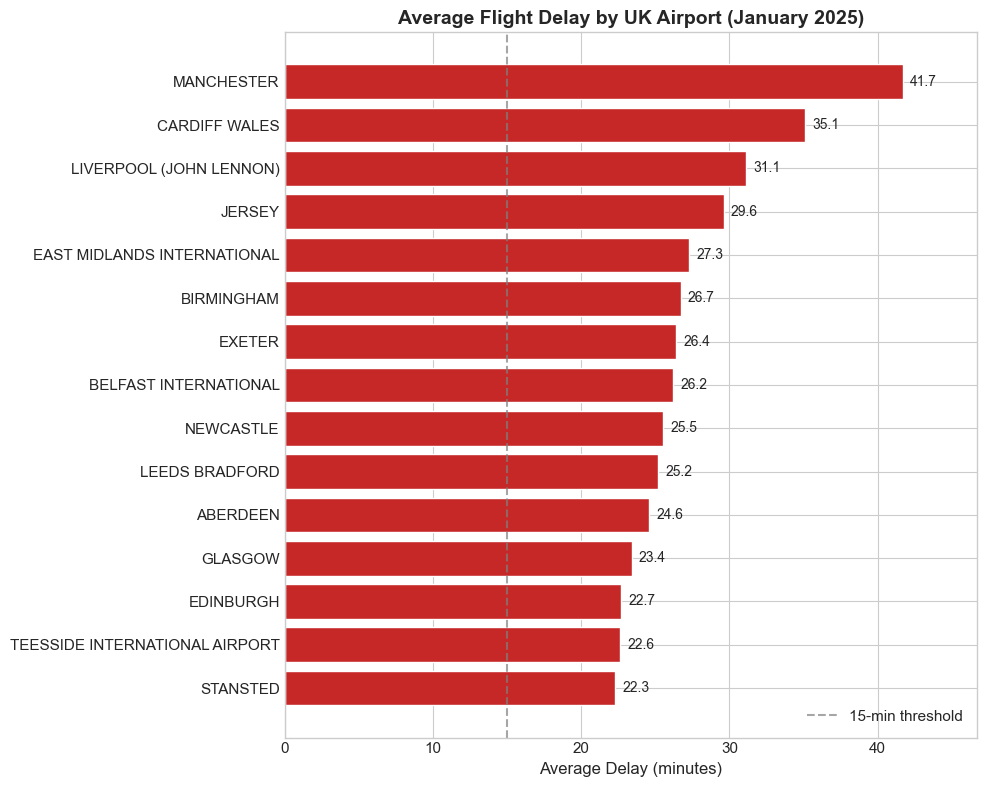

Figure saved: data//fig1_airport_delays.png


In [ ]:
# Prepare data for visualisation
delay_data = busy_airports.sort_values('average_delay_mins', ascending=True).tail(15)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal bar chart
colors = ['#c62828' if x > 20 else '#1565c0' for x in delay_data['average_delay_mins']]
bars = ax.barh(delay_data.index, delay_data['average_delay_mins'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, delay_data['average_delay_mins']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
            va='center', fontsize=10)

# Formatting
ax.set_xlabel('Average Delay (minutes)', fontsize=12)
ax.set_title('Average Flight Delay by UK Airport (January 2025)', fontsize=14, fontweight='bold')
ax.axvline(x=15, color='gray', linestyle='--', alpha=0.7, label='15-min threshold')
ax.legend(loc='lower right')
ax.set_xlim(0, max(delay_data['average_delay_mins']) + 5)

plt.tight_layout()
plt.savefig('data//fig1_airport_delays.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: data/fig1_airport_delays.png")

### Figure 2: Cancellation Rates by Airport

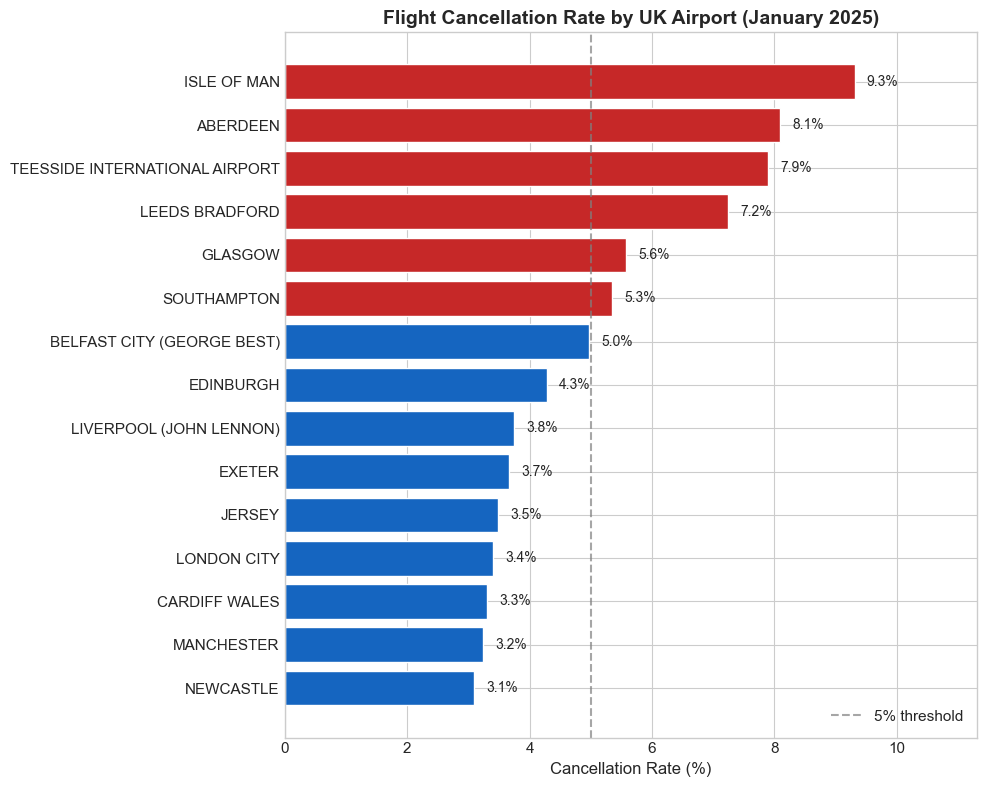

Figure saved: data/fig2_cancellation_rates.png


In [40]:
# Prepare data
cancel_data = busy_airports.sort_values('cancellation_rate', ascending=True).tail(15)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Horizontal bar chart
colors = ['#c62828' if x > 5 else '#1565c0' for x in cancel_data['cancellation_rate']]
bars = ax.barh(cancel_data.index, cancel_data['cancellation_rate'], color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, cancel_data['cancellation_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontsize=10)

# Formatting
ax.set_xlabel('Cancellation Rate (%)', fontsize=12)
ax.set_title('Flight Cancellation Rate by UK Airport (January 2025)', fontsize=14, fontweight='bold')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='5% threshold')
ax.legend(loc='lower right')
ax.set_xlim(0, max(cancel_data['cancellation_rate']) + 2)

plt.tight_layout()
plt.savefig('data//fig2_cancellation_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: data/fig2_cancellation_rates.png")

### Figure 3: Top Airlines Performance Comparison

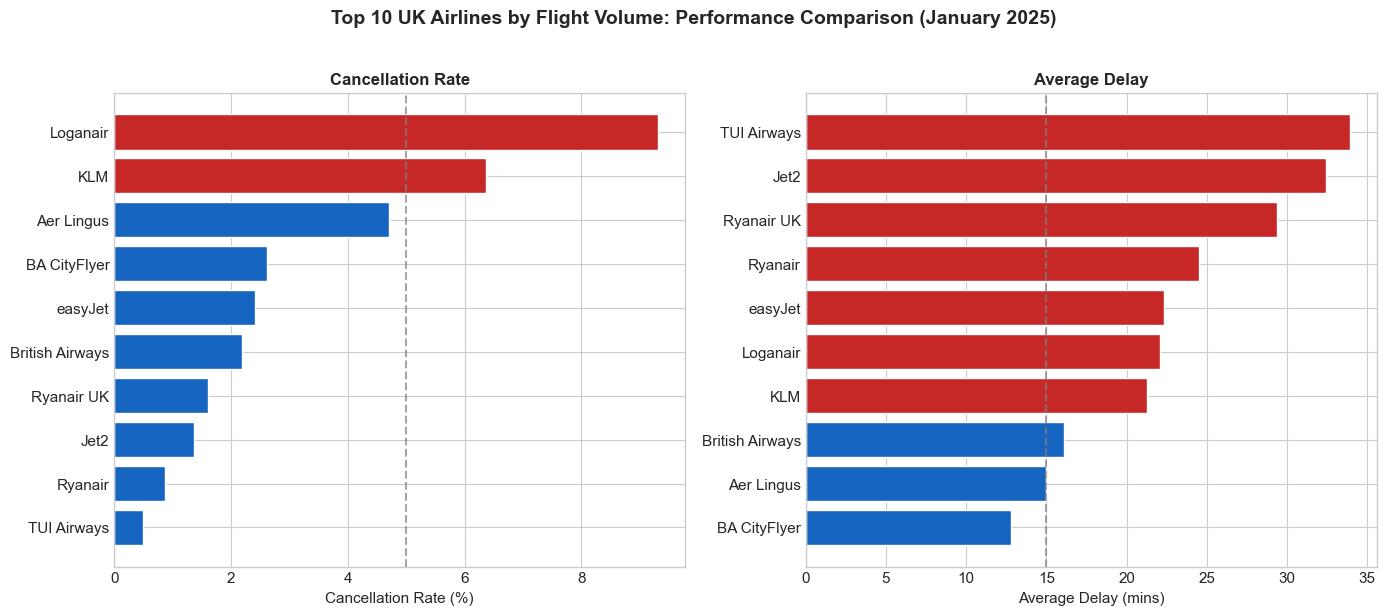

Figure saved: data/fig3_airline_comparison.png


In [41]:
# Prepare data for top 10 airlines
top10 = airline_stats.sort_values('number_flights_matched', ascending=False).head(10).copy()
top10 = top10.sort_values('cancellation_rate', ascending=True)

# Shorten airline names for display
name_map = {
    'BRITISH AIRWAYS PLC': 'British Airways',
    'EASYJET UK LTD': 'easyJet',
    'RYANAIR': 'Ryanair',
    'JET2.COM LTD': 'Jet2',
    'AER LINGUS': 'Aer Lingus',
    'LOGANAIR LTD': 'Loganair',
    'RYANAIR UK LTD': 'Ryanair UK',
    'KLM': 'KLM',
    'BA CITYFLYER LTD': 'BA CityFlyer',
    'TUI AIRWAYS LTD': 'TUI Airways'
}
top10.index = top10.index.map(lambda x: name_map.get(x, x))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Cancellation rate
colors1 = ['#c62828' if x > 5 else '#1565c0' for x in top10['cancellation_rate']]
ax1.barh(top10.index, top10['cancellation_rate'], color=colors1, edgecolor='white')
ax1.set_xlabel('Cancellation Rate (%)', fontsize=11)
ax1.set_title('Cancellation Rate', fontsize=12, fontweight='bold')
ax1.axvline(x=5, color='gray', linestyle='--', alpha=0.7)

# Right: Average delay
top10_delay = top10.sort_values('average_delay_mins', ascending=True)
colors2 = ['#c62828' if x > 20 else '#1565c0' for x in top10_delay['average_delay_mins']]
ax2.barh(top10_delay.index, top10_delay['average_delay_mins'], color=colors2, edgecolor='white')
ax2.set_xlabel('Average Delay (mins)', fontsize=11)
ax2.set_title('Average Delay', fontsize=12, fontweight='bold')
ax2.axvline(x=15, color='gray', linestyle='--', alpha=0.7)

fig.suptitle('Top 10 UK Airlines by Flight Volume: Performance Comparison (January 2025)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('data//fig3_airline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: data/fig3_airline_comparison.png")

### Figure 4: On-Time Performance Distribution

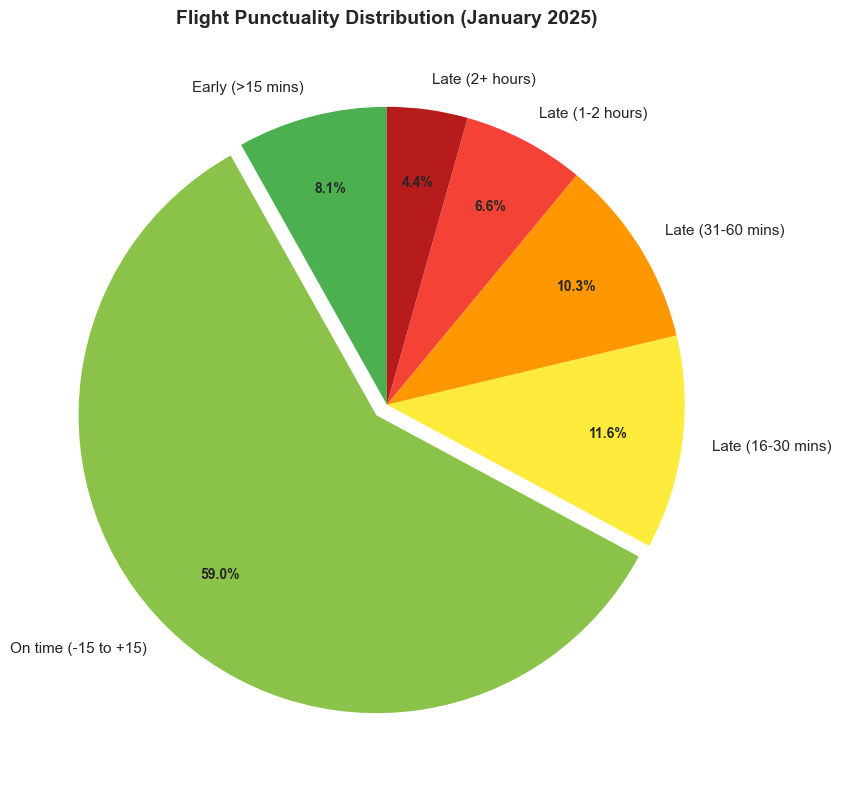

Figure saved: data/fig4_punctuality_distribution.png


In [42]:
# Calculate delay distribution categories
delay_categories = {
    'Early (>15 mins)': df_active['flights_more_than_15_minutes_early_percent'].mean(),
    'On time (-15 to +15)': (
        df_active['flights_15_minutes_early_to_1_minute_early_percent'].mean() +
        df_active['flights_0_to_15_minutes_late_percent'].mean()
    ),
    'Late (16-30 mins)': df_active['flights_between_16_and_30_minutes_late_percent'].mean(),
    'Late (31-60 mins)': df_active['flights_between_31_and_60_minutes_late_percent'].mean(),
    'Late (1-2 hours)': df_active['flights_between_61_and_120_minutes_late_percent'].mean(),
    'Late (2+ hours)': (
        df_active['flights_between_121_and_180_minutes_late_percent'].mean() +
        df_active['flights_between_181_and_360_minutes_late_percent'].mean() +
        df_active['flights_more_than_360_minutes_late_percent'].mean()
    )
}

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#4caf50', '#8bc34a', '#ffeb3b', '#ff9800', '#f44336', '#b71c1c']
explode = (0, 0.05, 0, 0, 0, 0)

wedges, texts, autotexts = ax.pie(
    delay_categories.values(), 
    labels=delay_categories.keys(),
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    pctdistance=0.75
)

# Style the text
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Flight Punctuality Distribution (January 2025)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data//fig4_punctuality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: data/fig4_punctuality_distribution.png")

### Figure 5: Flights vs Delay Scatter Plot

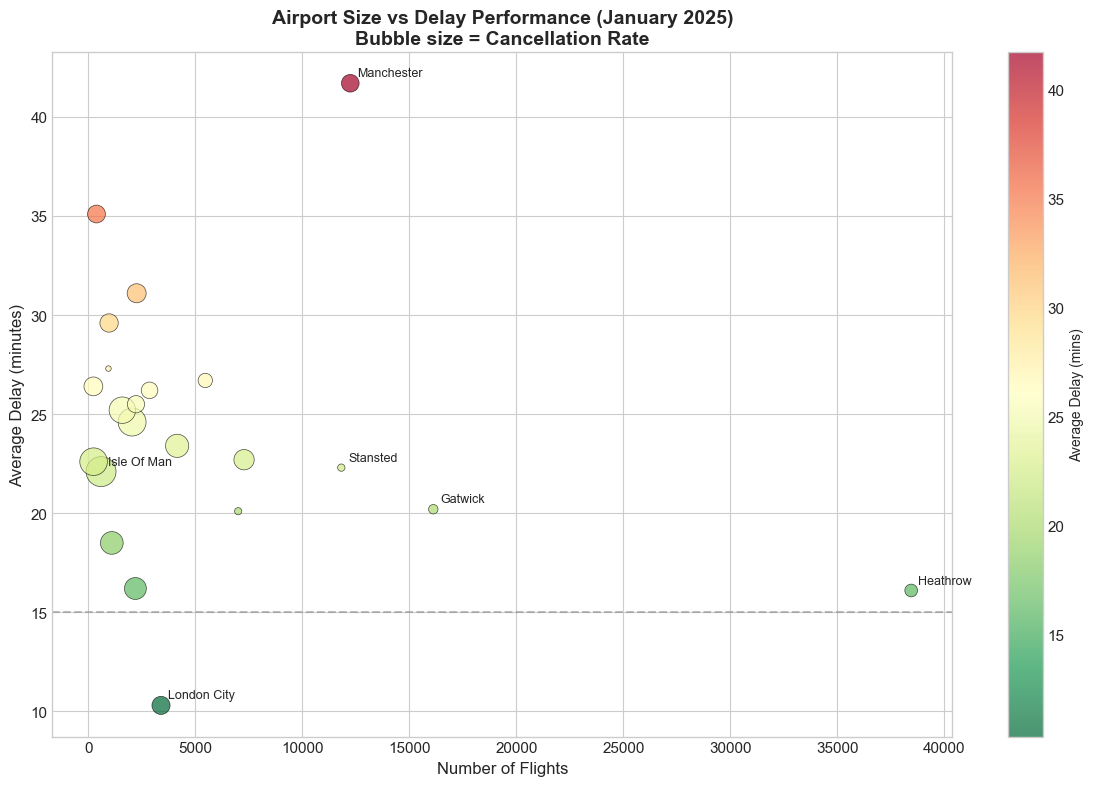

Figure saved: data/fig5_size_vs_delay.png


In [43]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    busy_airports['number_flights_matched'],
    busy_airports['average_delay_mins'],
    s=busy_airports['cancellation_rate'] * 50,  # Size by cancellation rate
    c=busy_airports['average_delay_mins'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

# Add airport labels for notable points
notable = ['HEATHROW', 'GATWICK', 'MANCHESTER', 'LONDON CITY', 'ISLE OF MAN', 'STANSTED']
for airport in notable:
    if airport in busy_airports.index:
        x = busy_airports.loc[airport, 'number_flights_matched']
        y = busy_airports.loc[airport, 'average_delay_mins']
        ax.annotate(airport.title(), (x, y), textcoords="offset points", 
                    xytext=(5, 5), fontsize=9)

# Formatting
ax.set_xlabel('Number of Flights', fontsize=12)
ax.set_ylabel('Average Delay (minutes)', fontsize=12)
ax.set_title('Airport Size vs Delay Performance (January 2025)\nBubble size = Cancellation Rate', 
             fontsize=14, fontweight='bold')
ax.axhline(y=15, color='gray', linestyle='--', alpha=0.5, label='15-min threshold')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average Delay (mins)', fontsize=10)

plt.tight_layout()
plt.savefig('data//fig5_size_vs_delay.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: data/fig5_size_vs_delay.png")

### Figure 6: Worst Performing Routes

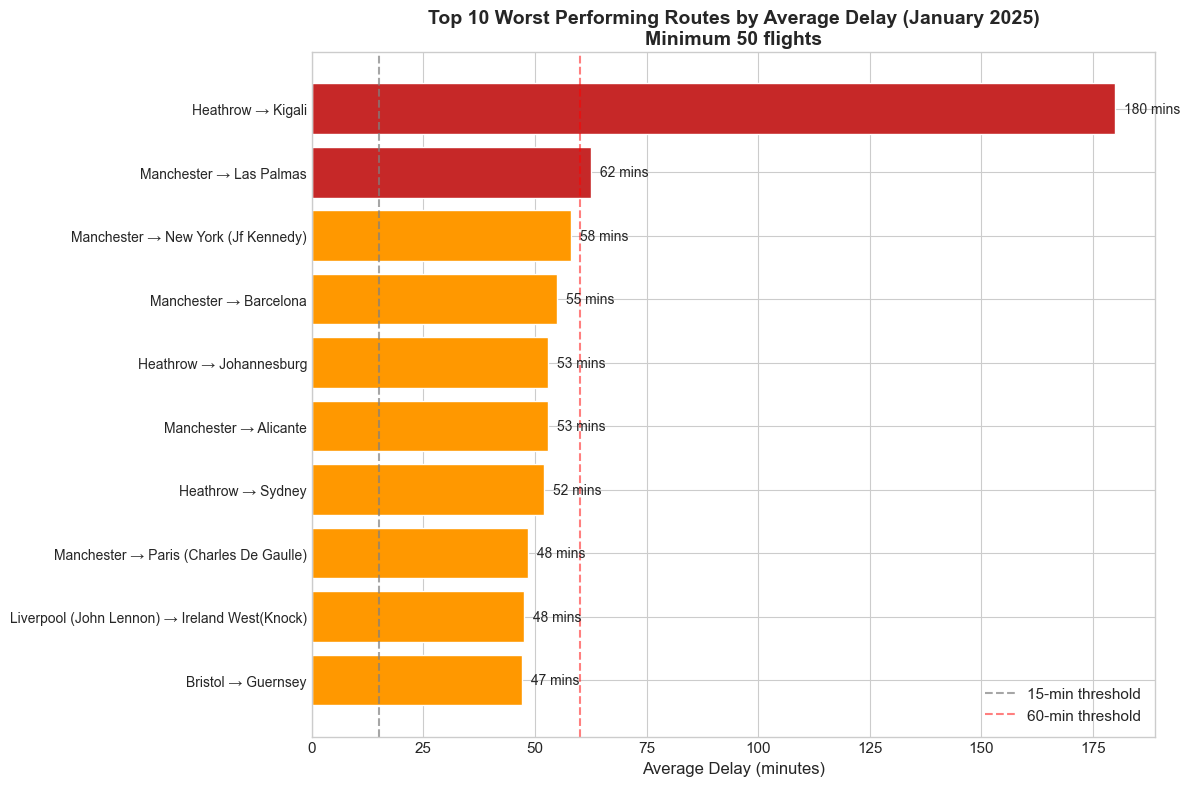

Figure saved: data/fig6_worst_routes.png


In [44]:
# Route analysis - worst performers
route_stats = df_active.groupby(
    ['reporting_airport', 'origin_destination', 'airline_name']
).agg({
    'number_flights_matched': 'sum',
    'average_delay_mins': 'mean'
}).round(1)

# Filter for routes with sufficient sample size
busy_routes = route_stats[route_stats['number_flights_matched'] >= 50].copy()
busy_routes = busy_routes.reset_index()

# Get worst 10 routes by delay
worst_routes = busy_routes.nlargest(10, 'average_delay_mins').copy()
worst_routes['route_label'] = worst_routes['reporting_airport'].str.title() + ' → ' + worst_routes['origin_destination'].str.title()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#c62828' if x > 60 else '#ff9800' if x > 30 else '#1565c0' for x in worst_routes['average_delay_mins']]
bars = ax.barh(range(len(worst_routes)), worst_routes['average_delay_mins'], color=colors, edgecolor='white')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, worst_routes['average_delay_mins'])):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:.0f} mins', va='center', fontsize=10)

# Set y-axis labels
ax.set_yticks(range(len(worst_routes)))
ax.set_yticklabels(worst_routes['route_label'], fontsize=10)

# Formatting
ax.set_xlabel('Average Delay (minutes)', fontsize=12)
ax.set_title('Top 10 Worst Performing Routes by Average Delay (January 2025)\nMinimum 50 flights', fontsize=14, fontweight='bold')
ax.axvline(x=15, color='gray', linestyle='--', alpha=0.7, label='15-min threshold')
ax.axvline(x=60, color='red', linestyle='--', alpha=0.5, label='60-min threshold')
ax.legend(loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('data//fig6_worst_routes.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: data/fig6_worst_routes.png")

## 5. Key Findings Summary

In [46]:
print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

# Finding 1: Best and worst airports by delay
best_airport = busy_airports['average_delay_mins'].idxmin()
worst_airport = busy_airports['average_delay_mins'].idxmax()
print(f"\n1. AIRPORT DELAYS")
print(f"   Best:  {best_airport.title()} ({busy_airports.loc[best_airport, 'average_delay_mins']:.1f} mins avg)")
print(f"   Worst: {worst_airport.title()} ({busy_airports.loc[worst_airport, 'average_delay_mins']:.1f} mins avg)")

# Finding 2: Cancellation rates
worst_cancel = busy_airports['cancellation_rate'].idxmax()
print(f"\n2. CANCELLATION RATES")
print(f"   Highest: {worst_cancel.title()} ({busy_airports.loc[worst_cancel, 'cancellation_rate']:.1f}%)")
print(f"   Heathrow: {busy_airports.loc['HEATHROW', 'cancellation_rate']:.1f}%")

# Finding 3: On-time performance
on_time = df_active['on_time_pct'].mean()
print(f"\n3. ON-TIME PERFORMANCE")
print(f"   Overall on-time rate: {on_time:.1f}%")
print(f"   Passengers delayed >15 mins: {100-on_time:.1f}%")

# Finding 4: Worst route
worst_route_idx = busy_routes['average_delay_mins'].idxmax()
worst_route_row = busy_routes.loc[worst_route_idx]
print(f"\n4. WORST ROUTE")
print(f"   {worst_route_row['reporting_airport'].title()} → {worst_route_row['origin_destination'].title()} ({worst_route_row['airline_name']})")
print(f"   Average delay: {worst_route_row['average_delay_mins']:.0f} minutes")

print("\n" + "="*60)

KEY FINDINGS SUMMARY

1. AIRPORT DELAYS
   Best:  London City (10.3 mins avg)
   Worst: Manchester (41.7 mins avg)

2. CANCELLATION RATES
   Highest: Isle Of Man (9.3%)
   Heathrow: 1.7%

3. ON-TIME PERFORMANCE
   Overall on-time rate: 66.0%
   Passengers delayed >15 mins: 34.0%

4. WORST ROUTE
   Heathrow → Kigali (RWANDAIR EXPRESS)
   Average delay: 180 minutes



## 6. Export Summary Tables

In [ ]:
# Export airport summary
airport_summary = busy_airports[['number_flights_matched', 'average_delay_mins', 'cancellation_rate']].copy()
airport_summary.columns = ['Flights', 'Avg Delay (mins)', 'Cancellation Rate (%)']
airport_summary = airport_summary.sort_values('Flights', ascending=False)
airport_summary.to_csv('airport_summary.csv')

print("Exported: airport_summary.csv")
airport_summary.head(10)

---

**Data Source:** UK Civil Aviation Authority, January 2025 Punctuality Statistics  
**Analysis:** Python (pandas, matplotlib, seaborn)